# Training Loss Curves (from logs)

Parsed directly from `7_model_training/logs/{crps_only,dfl_forecasts}_seed{N}.log` --
the stdout captures of the full retrain campaign, one line per epoch. Five seeds shown
as five side-by-side panels per family (not overlaid on one axis and not averaged --
different seeds early-stop at different epochs, so a mean+-std band across
misaligned-length trajectories would be misleading). The best (checkpointed,
early-stopping) epoch is marked with a vertical dashed line in every panel.

**What's actually available differs by family**, confirmed directly against each
training script's own print statement rather than assumed:
- **CRPS-only** (`train_crps_only.py`): both `train_pinball` and `val_pinball` are
  logged per epoch -- a genuine train-vs-val comparison.
- **DFL** (`dfl_train_utils.py`'s `train_one_config`): only **validation-set** metrics
  are logged per epoch (`val_fsurr`, `val_pinball`, `val_combined`) -- there is no
  per-epoch training-loss print for the DFL runs, so no train curve is shown for these;
  labelling one would misrepresent what's in the log.

## Setup — parsers

In [ ]:
from __future__ import annotations
import re
import pandas as pd
import matplotlib.pyplot as plt
from pyprojroot import here

LOG_DIR = here() / "7_model_training" / "logs"
SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]

CRPS_LINE = re.compile(
    r"^epoch\s*(\d+)\s+train_pinball=([\d.]+)\s+val_pinball=([\d.]+)\s+"
    r"\(([\d.]+)s\)\s+(\*best|\(patience)"
)
DFL_LINE = re.compile(
    r"^\[1stage (single-price|dual-price)\] epoch\s*(\d+)\s+"
    r"val_fsurr=([\d.]+)\s+val_pinball=([\d.]+)\s+val_combined=([\d.]+)\s+"
    r"skipped=(\d+)\s+grad_norm\(mean/max\)=([\d.]+)/([\d.]+)\s+"
    r"sat_frac\(train/val\)=([\d.]+)/([\d.]+)\s+"
    r"inaccurate\(train/val\)=(\d+)/(\d+)\s+"
    r"t_fwd\(train/val\)=([\d.]+)s/([\d.]+)s\s+t_bwd\(train\)=([\d.]+)s\s+(\*best|\(patience)"
)


def parse_crps_log(seed):
    rows = []
    with open(LOG_DIR / f"crps_only_seed{seed}.log") as f:
        for line in f:
            m = CRPS_LINE.match(line.strip())
            if m:
                rows.append({
                    "epoch": int(m.group(1)), "train_pinball": float(m.group(2)),
                    "val_pinball": float(m.group(3)), "seconds": float(m.group(4)),
                    "best": m.group(5) == "*best",
                })
    return pd.DataFrame(rows)


def parse_dfl_log(seed):
    rows = []
    with open(LOG_DIR / f"dfl_forecasts_seed{seed}.log") as f:
        for line in f:
            m = DFL_LINE.match(line.strip())
            if m:
                rows.append({
                    "mode": m.group(1), "epoch": int(m.group(2)),
                    "val_fsurr": float(m.group(3)), "val_pinball": float(m.group(4)),
                    "val_combined": float(m.group(5)), "skipped": int(m.group(6)),
                    "grad_norm_mean": float(m.group(7)), "grad_norm_max": float(m.group(8)),
                    "train_sat_frac": float(m.group(9)), "val_sat_frac": float(m.group(10)),
                    "train_inaccurate": int(m.group(11)), "val_inaccurate": int(m.group(12)),
                    "t_fwd_train": float(m.group(13)), "t_fwd_val": float(m.group(14)),
                    "t_bwd_train": float(m.group(15)),
                    "best": m.group(16) == "*best",
                })
    return pd.DataFrame(rows)


crps_logs = {seed: parse_crps_log(seed) for seed in SEEDS}
dfl_logs = {seed: parse_dfl_log(seed) for seed in SEEDS}

for seed in SEEDS:
    n_dfl_single = (dfl_logs[seed]["mode"] == "single-price").sum()
    n_dfl_dual = (dfl_logs[seed]["mode"] == "dual-price").sum()
    print(f"seed={seed}:  crps_only epochs={len(crps_logs[seed])}  "
          f"dfl single-price epochs={n_dfl_single}  dfl dual-price epochs={n_dfl_dual}")

seed=20240801:  crps_only epochs=14  dfl single-price epochs=18  dfl dual-price epochs=15
seed=20240802:  crps_only epochs=12  dfl single-price epochs=15  dfl dual-price epochs=15
seed=20240803:  crps_only epochs=11  dfl single-price epochs=11  dfl dual-price epochs=11
seed=20240804:  crps_only epochs=22  dfl single-price epochs=11  dfl dual-price epochs=19
seed=20240805:  crps_only epochs=13  dfl single-price epochs=36  dfl dual-price epochs=26


## All three families combined

One figure, 2 rows x 5 columns (one column per seed). Top row: `val_fsurr` (`f_dfl` on
the validation set) -- only DFL single-price and DFL dual-price have this, since
CRPS-only never computes a decision loss at all. Bottom row: `val_pinball` (`L_base`) --
shown for all three families, since this is the one metric genuinely common to every
training run, making it the direct apples-to-apples comparison. CRPS-only's
`train_pinball` is included too (thin dashed line) as the one train-vs-val comparison
available; there's no equivalent train curve for the DFL families (see the note above).
Each family's own early-stop epoch is marked with a thin vertical line in its own
colour.

## Time until best (checkpointed) epoch, per retrained forecaster

"Time" shown two ways: **epochs** until the checkpointed/early-stopping-selected epoch
was reached, and **wall-clock seconds** until that same point (cumulative per-epoch
training time, summed up to and including the best epoch) -- these can disagree, since
epoch duration itself isn't constant (DFL epochs vary with solver behaviour). Baseline
excluded -- it isn't one of the retrained forecasters and its own hyperparameter-search
log isn't in this same per-epoch format. Averaged across the 5 seeds, error bars = min-max range across seeds.

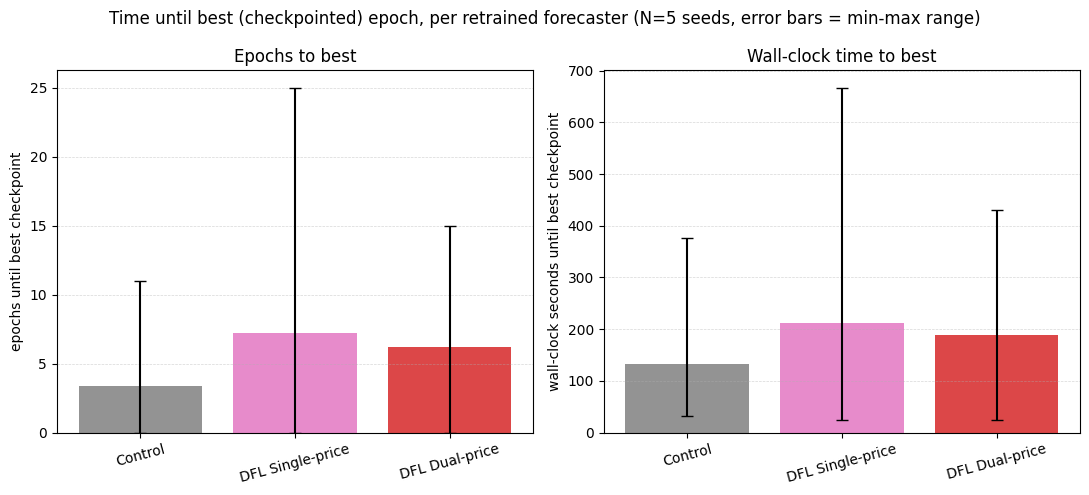

Control               epochs: [np.int64(3), np.int64(1), np.int64(0), np.int64(11), np.int64(2)]  seconds: [np.float64(121.7), np.float64(52.3), np.float64(32.8), np.float64(375.8), np.float64(80.2)]
DFL Single-price      epochs: [np.int64(7), np.int64(4), np.int64(0), np.int64(0), np.int64(25)]  seconds: [np.float64(196.8), np.float64(143.7), np.float64(26.3), np.float64(24.6), np.float64(667.3)]
DFL Dual-price        epochs: [np.int64(4), np.int64(4), np.int64(0), np.int64(8), np.int64(15)]  seconds: [np.float64(119.3), np.float64(139.4), np.float64(23.5), np.float64(229.2), np.float64(431.4)]


In [ ]:
def crps_time_to_best(seed):
    df = crps_logs[seed]
    best_epoch = df.loc[df["best"], "epoch"].max()
    seconds_to_best = df.loc[df["epoch"] <= best_epoch, "seconds"].sum()
    return best_epoch, seconds_to_best


def dfl_time_to_best(seed, mode):
    df = dfl_logs[seed]
    df = df[df["mode"] == mode]
    best_epoch = df.loc[df["best"], "epoch"].max()
    up_to_best = df[df["epoch"] <= best_epoch]
    seconds_to_best = (up_to_best["t_fwd_train"] + up_to_best["t_fwd_val"] + up_to_best["t_bwd_train"]).sum()
    return best_epoch, seconds_to_best


FAMILY_COLORS = {"Control": "grey", "DFL Single-price": "C6", "DFL Dual-price": "C3"}
FAMILY_ORDER = list(FAMILY_COLORS)

epochs_by_family = {"Control": [], "DFL Single-price": [], "DFL Dual-price": []}
seconds_by_family = {"Control": [], "DFL Single-price": [], "DFL Dual-price": []}
for seed in SEEDS:
    e, s = crps_time_to_best(seed)
    epochs_by_family["Control"].append(e); seconds_by_family["Control"].append(s)
    e, s = dfl_time_to_best(seed, "single-price")
    epochs_by_family["DFL Single-price"].append(e); seconds_by_family["DFL Single-price"].append(s)
    e, s = dfl_time_to_best(seed, "dual-price")
    epochs_by_family["DFL Dual-price"].append(e); seconds_by_family["DFL Dual-price"].append(s)

import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
x = np.arange(len(FAMILY_ORDER))

def minmax_err(values_by_family):
    """Asymmetric [mean-min, max-mean] error bars, matplotlib's (2, N) yerr format."""
    means = np.array([np.mean(values_by_family[f]) for f in FAMILY_ORDER])
    mins = np.array([np.min(values_by_family[f]) for f in FAMILY_ORDER])
    maxs = np.array([np.max(values_by_family[f]) for f in FAMILY_ORDER])
    return means, np.vstack([means - mins, maxs - means])


epoch_means, epoch_err = minmax_err(epochs_by_family)
axes[0].bar(x, epoch_means, yerr=epoch_err, capsize=4,
            color=[FAMILY_COLORS[f] for f in FAMILY_ORDER], alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(FAMILY_ORDER, rotation=15)
axes[0].set_ylabel("epochs until best checkpoint")
axes[0].set_title("Epochs to best")
axes[0].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

sec_means, sec_err = minmax_err(seconds_by_family)
axes[1].bar(x, sec_means, yerr=sec_err, capsize=4,
            color=[FAMILY_COLORS[f] for f in FAMILY_ORDER], alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(FAMILY_ORDER, rotation=15)
axes[1].set_ylabel("wall-clock seconds until best checkpoint")
axes[1].set_title("Wall-clock time to best")
axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

fig.suptitle("Time until best (checkpointed) epoch, per retrained forecaster (N=5 seeds, error bars = min-max range)", fontsize=12)
fig.tight_layout()
plt.show()

for f in FAMILY_ORDER:
    print(f"{f:20s}  epochs: {epochs_by_family[f]}  seconds: {[round(s,1) for s in seconds_by_family[f]]}")